In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("lec_act_6_classes_and_drawing.ipynb")

# Classes and drawing

Slides for the lecture activity and lab: https://docs.google.com/presentation/d/1N7vEXDZVZikuHGMLDHB3lX1q4pSNJdKxboy5Sto-Dl0/edit?usp=sharing 

In prior assignments, we packaged up data into dictionaries, and passed them into function. But dealing with dictionaries can be cumbersome:

* Accessing an item in a dictionary involves a lot of typing; you need to type `dict["name_of_item"]`.
* It can be hard to remember what keys are available in the dictionary, and what they are named.
* There is no direct relationship between dictionaries and the functions that accept them; you have to remember which functions accept which dictionaries, and what keys they need.

Python (along with other "object-oriented" programming languages) have a special way to specify a collection of data along with related functions: _classes_. Like with a dictionary, classes contain named items. But classes also contain named _functions_ that operate on those items.

* With a dictionary, you access property `h_u` as `dict["h_u"]`. With classes, you access property `h_u` as `obj.h_u`, which is far easier to type.
* With a dictionary, you can pass the dictionary to a function via `my_function(dict)`. With classes, you can define `my_function` as part of the class, and call `obj.my_function()`. `my_function` receives `obj` as its first parameter, and can access all of its properties.

In this lecture activity, we will explore classes with a simple example, which will help you work with classes during the lab and homework assignment. Then, we will draw a part of the quarter car that is needed for Lab 6.


In [21]:
# The usual imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
# Enable animations to work
%matplotlib widget

## `Animal` class

Below, we've defined an `Animal` class. You can see how we use it to make `Animal`s, and how it has functions that can be called "on" an animal.

In [ ]:
class Animal:
    def __init__(self, name, sound, weight):
        """
        Creates a new animal with name `name`, sound `sound`, and weight `weight`. This special method is called a _constructor_ because it contains the logic needed to construct a new `Animal`.
        @param self - The special 'self' variable refers to one specific animal. You will see 'self' as the first argument to all of the methods on Animal
        @param name - The name of the animal
        @param sound - The sound the animal makes
        @param weight - The weight of the animal in kg.
        """
        self.name = name
        self.sound = sound
        self.weight = weight

    def make_sound(self):
        """
        Causes the animal to make a sound.
        @param self - The current animal.
        """
        return f"{self.name} says '{self.sound}'"
    
    def say_hi(self, other_animal):
        """
        GUIDES: Make the animal say hi to the other animal! ("dog says hi to cat")
        """
        return f"{self.name} says hi to {other_animal.name}"
    
# Make a dog and a cat
dog = Animal(name="dog", sound="bark", weight=30.0)
cat = Animal(name="cat", sound="meow", weight=4.5)

# Read the dog's name.
print(dog.name)
# Call make_sound() on the dog.
print(dog.make_sound())
print(cat.name)
print(cat.make_sound())

# You can pass _other_ arguments to functions defined on classes, too!
print(dog.say_hi(cat))

dog
dog says 'bark'
cat
cat says 'meow'
dog says hi to cat


In [19]:
grader.check("animal_classes")

animal_classes results: All test cases passed!

## Van transportation

Imagine you operate a pet transport company, but your van can only handle so many kilograms of animals. You need to calculate their combined weight.

Also, some animals need to be transported in cages, while others can roam free, so we need to take the weight of the cages in consideration as well.

Let's use classes to represent these animals, and write a function to calculate their combined weight.

In [30]:
class Cage:
    def __init__(self, animal, cage_weight):
        # GUIDES: Assign animal and cage_weight to properties on self.
        # GUIDES: Assign the sum of the animal's weight and cage_weight to self.weight.
        self.animal = animal
        self.cage_weight = cage_weight
        self.weight = cage_weight + animal.weight

In [47]:
def calculate_weight(items):
    # GUIDES: Add up the combined weight() of the items. Although some items are Animals and some are Cages,
    # they all have a weight() function!

    sum = 0

    for item in items:
        sum += item.weight

    return sum

In [48]:
caged_cat = Cage(cat, 3)
caged_dog = Cage(dog, 10)

assert np.isclose(calculate_weight([cat, dog, caged_cat, caged_dog]), 82.0)

In [49]:
grader.check("new_classes")

new_classes results: All test cases passed!

# Draw a spring

Shifting gears a bit (pun partially intended), the lab involves using classes to draw a quarter car at rest, and then using that to animate the quarter car driving down a road. 

In this lecture activity, we will start by drawing the spring, which is the most interesting part to draw.

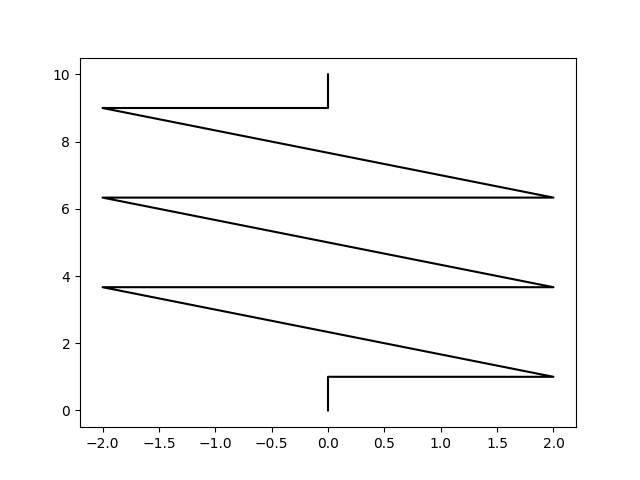

In [50]:
fig, axs = plt.subplots()

# A spring of diameter/width 4 wavers between +2 and -2 on the x axis.
# We draw it with three "coils" and a straight rod on each end (the [0, 0]).
spring_X = np.array([0, 0, 2, -2, 2, -2, 2, -2, 0, 0])
# The spring splits its height between the rods on either end and the three coils in the center.
# In this example, the rods have height 1, and the three coils are of height 8 total.
spring_Y = np.array([0, 1, 1, 1 + 8/3, 1 + 8/3, 1 + 2*8/3, 1 + 2*8/3, 1 + 3*8/3, 1 + 3*8/3, 1 + 3*8/3 + 1])

# 'k' is a format string that tells matplotlib to plot this in black.
axs.plot(spring_X, spring_Y, 'k')

plt.show()

In [63]:
def draw_spring(axs, width, height, x=0, y=0):
    """
    Draws a spring, starting at x and y, with the given width and height.
    The spring ends in two rods that are each 5% of the total height, and the middle contains
    three coils.

    You can ignore x and y for the first part of the problem.
    """

    # A spring of diameter/width 4 wavers between +2 and -2 on the x axis.
    # We draw it with three "coils" and a straight rod on each end (the [0, 0]).
    spring_X = np.array([x, x, width/2, -width/2, width/2, -width/2, width/2, -width/2, x, x])
    # The spring splits its height between the rods on either end and the three coils in the center.
    # In this example, the rods have height 1, and the three coils are of height 8 total.
    spring_Y = np.array([0, 1, 1, 1 + height/3, 1 + height/3, 1 + 2*height/3, 1 + 2*height/3, 1 + 3*height/3, 1 + 3*height/3, 1 + 3*height/3 + 1])

    # 'k' is a format string that tells matplotlib to plot this in black.
    axs.plot(spring_X, spring_Y, 'k')


    

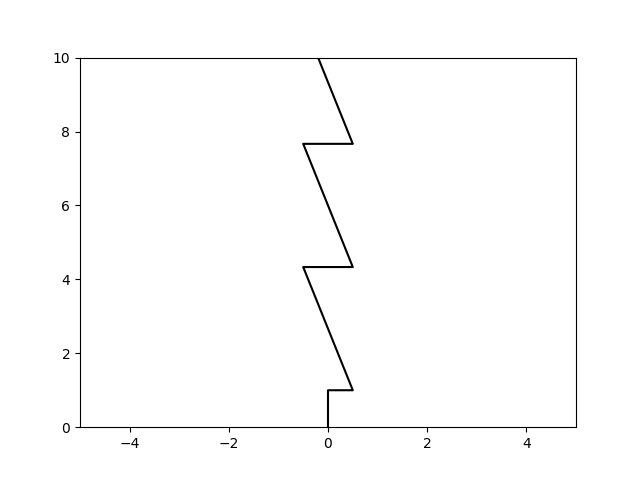

In [64]:
# Check code - draw a tall spring
fig_tall, axs_tall = plt.subplots()
axs_tall.set_xlim([-5, 5])
axs_tall.set_ylim([0, 10])
draw_spring(axs=axs_tall, width=1, height=10)
plt.show()

In [ ]:
grader.check("draw_spring")

Now, we want to be able to draw the spring at a particular x and y location on the graph. This will be important for drawing both springs in our diagram. Modify the function above to translate the X and Y coordinates by `x` and `y`, then run the code below to plot a nice collection of springs.

In [ ]:
# Check code: Draw three springs of varying sizes at different offsets
fig_manysprings, axs_manysprings = plt.subplots()
axs_manysprings.set_xlim([-5, 5])
axs_manysprings.set_ylim([0, 10])
draw_spring(axs=axs_manysprings, width=1, height=10)
draw_spring(axs=axs_manysprings, width=2, height=4, x=3, y=1)
draw_spring(axs=axs_manysprings, width=0.5, height=1, x=-4, y=4)
plt.show()

In [ ]:
# Enable animations to work
%matplotlib widget

In [ ]:
# Make a spring of width 3 compress from 10 to 3 over 30 frames in an unrealistically linear fashion.
spring_height = np.linspace(10, 3, 30)
fig_animation, axs_animation = plt.subplots()
def draw_spring_frame(spring_height):
    # Clear the plot
    axs_animation.clear()
    # Ensure plot is 10 high.
    axs_animation.set_ylim(0, 10)
    axs_animation.set_xlim(-5, 5)
    draw_spring(axs=axs_animation, width=3, height=spring_height)

# We disable repeats for animations because the animation will repeat forever, which can cause issues when re-running a cell.
spring_anim = animation.FuncAnimation(fig_animation, draw_spring_frame, frames=spring_height, interval=1/30 * 1000, repeat=False)
plt.show()

In [ ]:
grader.check("draw_spring_offsets")

## Hours and collaborators
Required for every assignment - fill out before you hand-in.

Listing names and websites helps you to document who you worked with and what internet help you received in the case of any plagiarism issues. You should list names of anyone (in class or not) who has substantially helped you with an assignment - or anyone you have *helped*. You do not need to list TAs.

Listing hours helps us track if the assignments are too long.

In [ ]:

# List of names (creates a set)
worked_with_names = {"not filled out"}
# List of URLS SP26 (creates a set)
websites = {"not filled out"}
# Approximate number of hours, including lab/in-class time
hours = -1.5

In [ ]:
grader.check("hours_collaborators")

### To submit

Double check your plots. 

- Submit this .ipynb file to lecture activity 6 (classes and drawing)

Failures: None expected